# CO2 Storage Capacity Screening: Probabilistic Estimate

**Goal:** rank five candidate saline aquifers on probabilistic *effective* capacity —
volumetric storage gated by injectivity.

**Technique highlights**
* Distribution-shaped inputs (beta for efficiency, lognormal for permeability)
* Capacity **and** injectivity — the screening mistake this notebook avoids
* Spearman-based tornado: which uncertainty is worth appraisal money?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Candidate aquifers

In [2]:
CANDS = pd.DataFrame([
    # name, area km2 (min,mode,max), thickness m, phi, depth m, perm mD (ln mu, ln sd)
    ("Alpha",  (300, 500, 800),  (40, 70, 120), (0.14, 0.20, 0.26), 1_400, (3.4, 0.8)),
    ("Bravo",  (150, 260, 400),  (60, 110, 160), (0.16, 0.22, 0.28), 1_900, (4.1, 0.7)),
    ("Charlie",(600, 900, 1300), (20, 35, 60),  (0.10, 0.15, 0.21), 1_100, (2.2, 0.9)),
    ("Delta",  (200, 350, 550),  (80, 130, 200), (0.12, 0.17, 0.23), 2_600, (3.0, 0.8)),
    ("Echo",   (400, 650, 950),  (30, 55, 90),  (0.13, 0.19, 0.25), 1_600, (4.6, 0.6)),
], columns=["name", "area_km2", "thick_m", "phi", "depth_m", "perm_ln"])
CANDS.to_csv("aquifer_candidates.csv", index=False)

def rho_co2(depth_m):
    """Supercritical CO2 density (kg/m3) vs depth — hydrostatic/geothermal proxy."""
    return np.clip(150 + 0.45 * depth_m - 6e-5 * depth_m ** 2, 150, 800)

N = 8_000
INJ_YEARS, N_WELLS, MAX_DP = 30, 6, 120  # bar allowed above initial pressure

results, samples_store = {}, {}
for _, c in CANDS.iterrows():
    area = rng.triangular(*c.area_km2, N) * 1e6          # m2
    h = rng.triangular(*c.thick_m, N)
    phi = rng.triangular(*c.phi, N)
    E = rng.beta(2, 5, N) * 0.05 + 0.01                  # 1-6% efficiency
    rho = rho_co2(c.depth_m) * rng.normal(1, 0.05, N)
    cap_mt = area * h * phi * rho * E / 1e9              # Mt CO2

    perm = rng.lognormal(*c.perm_ln, N)                  # mD
    visc, re_rw = 6e-5, np.log(2_000 / 0.1)              # Pa·s, radial geometry
    q_well = (2 * np.pi * perm * 9.87e-16 * h * MAX_DP * 1e5
              / (visc * re_rw))                          # m3/s reservoir vol
    inj_mt = q_well * rho * 3.15e7 * N_WELLS * INJ_YEARS / 1e9

    effective = np.minimum(cap_mt, inj_mt)
    results[c["name"]] = effective
    samples_store[c["name"]] = {"area": area, "h": h, "phi": phi, "E": E,
                                "perm": perm, "cap": cap_mt, "inj": inj_mt,
                                "eff": effective}

res = pd.DataFrame({k: {"P90": np.percentile(v, 10), "P50": np.percentile(v, 50),
                        "P10": np.percentile(v, 90)} for k, v in results.items()}).T
print(res.round(0).to_string(), "\n(Mt CO2 effective capacity, 30-yr program)")

          P90    P50    P10
Alpha    65.0  119.0  212.0
Bravo    64.0  114.0  202.0
Charlie  32.0   62.0  111.0
Delta    85.0  155.0  270.0
Echo     64.0  117.0  208.0 
(Mt CO2 effective capacity, 30-yr program)


## 2. Ranking view — and where injectivity bites

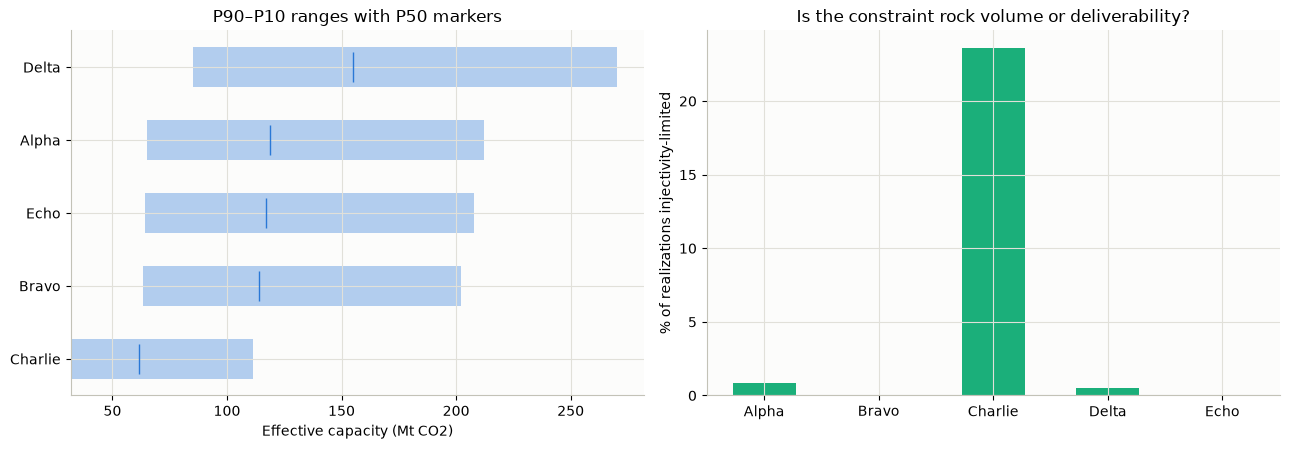

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
order = res.P50.sort_values(ascending=True).index
for i, name in enumerate(order):
    v = results[name]
    axes[0].barh(i, res.loc[name, "P10"] - res.loc[name, "P90"],
                 left=res.loc[name, "P90"], height=0.55, color=PALETTE[0], alpha=0.35)
    axes[0].plot([res.loc[name, "P50"]], [i], marker="|", ms=22, color=PALETTE[0])
axes[0].set_yticks(range(len(order)), order)
axes[0].set(xlabel="Effective capacity (Mt CO2)", title="P90–P10 ranges with P50 markers")

for i, name in enumerate(CANDS.name):
    s = samples_store[name]
    frac_limited = (s["inj"] < s["cap"]).mean()
    axes[1].bar(i, frac_limited * 100, color=PALETTE[5] if frac_limited > 0.5 else PALETTE[1],
                width=0.55)
axes[1].set_xticks(range(len(CANDS)), CANDS.name)
axes[1].set(ylabel="% of realizations injectivity-limited",
            title="Is the constraint rock volume or deliverability?")
plt.tight_layout()
plt.show()

## 3. Tornado — what should appraisal measure first?

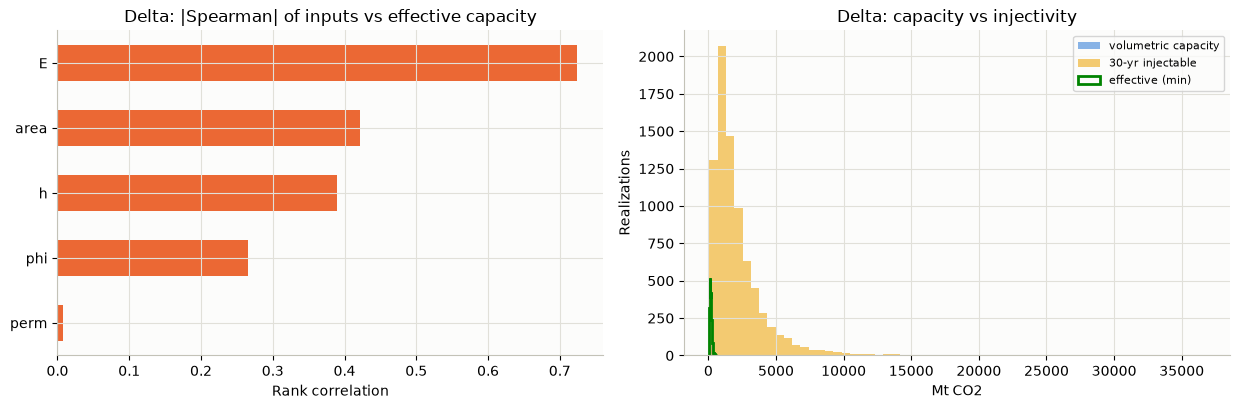

In [4]:
best = res.P50.idxmax()
s = samples_store[best]
tornado = {k: abs(spearmanr(s[k], s["eff"]).statistic)
           for k in ["area", "h", "phi", "E", "perm"]}
tornado = dict(sorted(tornado.items(), key=lambda kv: kv[1]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].barh(list(tornado), list(tornado.values()), color=PALETTE[7], height=0.55)
axes[0].set(title=f"{best}: |Spearman| of inputs vs effective capacity",
            xlabel="Rank correlation")

axes[1].hist(s["cap"], bins=60, alpha=0.55, color=PALETTE[0], label="volumetric capacity")
axes[1].hist(s["inj"], bins=60, alpha=0.55, color=PALETTE[2], label="30-yr injectable")
axes[1].hist(s["eff"], bins=60, histtype="step", lw=2, color=PALETTE[3],
             label="effective (min)")
axes[1].set(xlabel="Mt CO2", ylabel="Realizations", title=f"{best}: capacity vs injectivity")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Conclusions

* Ranking on **effective capacity** reorders the candidates versus naive volumetrics:
  the largest rock volume (Charlie) is injectivity-limited in most realizations, while
  high-permeability Echo converts more of its volume into bankable capacity.
* The tornado tells the appraisal program what to buy: for the leading candidate the
  efficiency factor and permeability dominate — i.e., an injection test is worth more
  than more seismic.
* P10/P50/P90 statements fall out naturally, matching how storage resources are
  reported (SRMS-style thinking).
* **Next step:** pressure-space interference between wells (capacity is shared), plume
  footprint vs lease boundary, and containment-risk screening as a separate gate.